# RESEARCH REPORT: TLT MATH NOTEBOOK

**Title:** Topics – A Theorem from Everything to Nothing:

**Date:** December 2025 + Addendum April 2026

**Writer:** G.P.J.W. Quint

**Subject:** Math, Digital Physics, Cosmology, Complexity Theory, Computational Ontology

I am using a notebook with 16GB RAM Memeory and NVIDIA-SMI PROCESSOR to visualize and create a ledger of informayional weight. The code can be saperated in a class or repository I will add later for my other experiments.

In [1]:
# SETUP:
!pip install --quiet qiskit qiskit-aer qiskit-algorithms pylatexenc matplotlib numpy pandas google-cloud-bigquery google-auth

In [2]:
!nvidia-smi

Thu Apr 30 12:55:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             24W /  300W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 📦 CEL 1: INSTALL & IMPORT

In [3]:
import os
import io
import time
import datetime
import hashlib
import numpy as np
import pandas as pd
import uuid
import scipy.stats


from IPython.display import display
import matplotlib.pyplot as plt

# Qiskit & Quantum Algorithms
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import pauli_feature_map, efficient_su2, EfficientSU2, GroverOperator
from qiskit.quantum_info import partial_trace, Statevector, state_fidelity, DensityMatrix, entropy
from qiskit_algorithms.optimizers import SPSA
from qiskit.visualization import plot_bloch_multivector, plot_state_city

# Google Cloud
from google.cloud import bigquery, storage
from google.api_core.exceptions import NotFound
from google.auth.exceptions import DefaultCredentialsError

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning) # 🤫 Snoer Qiskit de mond

print("✅ Cel 1: Alle modules succesfully loaded!")

✅ Cel 1: Alle modules succesfully loaded!


# ☁️ CEL 2: GCP CLOUD CONFIGURATIE & KNOWLEDGE GRAPH SETUP

In [4]:
# ⚠️ REPLACE Values with your own gcp project

PROJECT_ID = "your-gcp-project" # @param {type:"string"}
DATASET_ID = "tlf_dataset" # @param {type:"string"}
DATASET_LOCATION = "europe-west4" # @param {type:"string"}

# --- Big Query CONFIGURATION ---

TABLE_ID = "tlf_quantum_ledger" # @param {type:"string"}
TABLE_REF = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"

TIMELINE_TABLE_ID = "retrodiction_timeline" # @param {type:"string"}
TIMELINE_TABLE_REF = f"{PROJECT_ID}.{DATASET_ID}.{TIMELINE_TABLE_ID}"

BUCKET_NAME = "tlf-bucket" # @param {type:"string"}
RESET_LEDGER = False # @param {type:"boolean"}

QUBITS = 16 # @param {type:"integer"}



In [5]:
print("⚙️ Initialize GCP connection...")
try:
    bq_client = bigquery.Client(project=PROJECT_ID)
    gcs_client = storage.Client(project=PROJECT_ID)

    # Bucket Controle & Auto-Create
    try:
        bucket = gcs_client.get_bucket(BUCKET_NAME)
        print(f"  ↳ ✅ Connected to GCP bucket: {BUCKET_NAME}")
    except NotFound:
        print(f"  ↳ ⚠️ Storage bucket '{BUCKET_NAME}' does not exist. Creating...")
        bucket = gcs_client.bucket(BUCKET_NAME)
        bucket.storage_class = "STANDARD"
        # Gebruik dezelfde locatie als je BigQuery dataset voor de beste performance
        new_bucket = gcs_client.create_bucket(bucket, location=DATASET_LOCATION)
        print(f"  ↳ ✅ New bucket created: {new_bucket.name}")

    # 1. Dataset Controle
    dataset_ref = f"{PROJECT_ID}.{DATASET_ID}"
    try:
        bq_client.get_dataset(dataset_ref)
    except NotFound:
        dataset = bigquery.Dataset(dataset_ref)
        dataset.location = "europe-west4"
        bq_client.create_dataset(dataset, timeout=30)
        print("  ↳ New BigQuery dataset created.")

    # 2. Tabel Reset (Optioneel)
    if RESET_LEDGER:
        print("  🧹 RESET_LEDGER ACTIVE: Table being deleted...")
        bq_client.delete_table(TABLE_REF, not_found_ok=True)
        time.sleep(5)

    # 3. Knowledge Graph Ledger (Tabel) Setup
    try:
        bq_client.get_table(TABLE_REF)
        print(f"  ↳ ✅ Connected with existing Ledger: {TABLE_ID}")
    except NotFound:
        schema = [
            bigquery.SchemaField("timestamp", "TIMESTAMP"),
            bigquery.SchemaField("event_id", "STRING"),
            bigquery.SchemaField("model_path", "STRING"),
            bigquery.SchemaField("friction_score", "FLOAT"),
            bigquery.SchemaField("qubit_topology", "STRING"),
            bigquery.SchemaField("input_hash", "STRING"),
        ]
        table = bigquery.Table(TABLE_REF, schema=schema)
        bq_client.create_table(table, timeout=30)
        print(f"  ↳ ✅ New Knowledge Graph Ledger created: {TABLE_ID}")

    cloud_actief = True
except Exception as e:
    cloud_actief = False
    print(f"⚠️ Cloud error: {e}. Check autentication and bucket name!")

⚙️ Initialize GCP connection...
  ↳ ✅ Connected to GCP bucket: tlf-bucket
  ↳ ✅ Connected with existing Ledger: tlf_quantum_ledger


# 🧠 CEL 3: QUANTUM NEURAL NETWORK

In [6]:
print(f"⚙️ Bouwen van Deep Light-Cone Architectuur op {QUBITS} Qubits...")

# ==============================================================================
# 🔥 SIMULATOR SETUP
# ==============================================================================
try:
    from qiskit_aer import AerSimulator
    try:
        simulator = AerSimulator(method='statevector', device='GPU')
        print("⚡ Succes! Verbonden met Qiskit Aer (GPU).")
    except Exception:
        simulator = AerSimulator(method='statevector', device='CPU')
        print("⚠️ GPU niet gepakt. Fallback naar CPU.")
except ImportError:
    from qiskit.providers.basic_provider import BasicProvider
    simulator = BasicProvider().get_backend('basic_simulator')
    print("⚠️ Fallback naar BasicProvider.")

def create_qnn():
    """Bouwt een extreem diep circuit zodat de lichtkegel het hele systeem bereikt."""
    feat = pauli_feature_map(feature_dimension=QUBITS, reps=1, paulis=['Z'])

    # 🔥 OPTIE 1: 15 LAGEN DIEP 🔥
    # - su2_gates=['ry', 'rx']: De Ry-brug (voor de Z-fase) en Rx (voor de XOR flip)
    # - entanglement='linear': Netjes qubit voor qubit, geen chaotisch spinnenweb
    # - reps=15: Precies genoeg lagen om informatie van qubit 0 naar 15 te verplaatsen
    ansatz = EfficientSU2(num_qubits=QUBITS, su2_gates=['ry', 'rx'], entanglement='linear', reps=15)

    qnn = QuantumCircuit(QUBITS)
    qnn.compose(feat, inplace=True)
    qnn.compose(ansatz, inplace=True)

    print(f"   ↳ Transpilen van het diepe circuit (reps=15)...")
    qnn_transpiled = transpile(qnn, simulator)

    return qnn_transpiled, feat, ansatz

qnn_model, feat_map, ansatz_circuit = create_qnn()
print(f"✅ Deep Model gereed: Liefst {ansatz_circuit.num_parameters} trainbare synapsen!")

def measure_friction(weights, cipher_vec, plain_vec):
    bind_c = dict(zip(feat_map.parameters, cipher_vec)) | dict(zip(ansatz_circuit.parameters, weights))
    qc_c = qnn_model.assign_parameters(bind_c)
    state_c = Statevector(qc_c)

    bind_p = dict(zip(feat_map.parameters, plain_vec)) | dict(zip(ansatz_circuit.parameters, np.zeros(len(weights))))
    qc_p = qnn_model.assign_parameters(bind_p)
    state_p = Statevector(qc_p)

    return float(1.0 - state_fidelity(state_c, state_p))

⚙️ Bouwen van Deep Light-Cone Architectuur op 16 Qubits...
⚡ Succes! Verbonden met Qiskit Aer (GPU).
   ↳ Transpilen van het diepe circuit (reps=15)...
✅ Deep Model gereed: Liefst 512 trainbare synapsen!


# 💾 CEL 4-A: Linear Causality Ledger (XOR Linear Key)

In [7]:
def generate_128bit_xor():
    plain_bytes = os.urandom(16)
    xor_key = os.urandom(16)
    cipher_bytes = bytes([p ^ k for p, k in zip(plain_bytes, xor_key)])

    plain_vec = (np.frombuffer(plain_bytes, dtype=np.uint8).astype(float) / 127.5) - 1.0
    cipher_vec = (np.frombuffer(cipher_bytes, dtype=np.uint8).astype(float) / 127.5) - 1.0
    return plain_bytes, plain_vec, cipher_vec

# --- (Local Cost) ---
def measure_local_friction(weights, cipher_vec, plain_vec):
    bind_c = dict(zip(feat_map.parameters, cipher_vec)) | dict(zip(ansatz_circuit.parameters, weights))
    qc_c = qnn_model.assign_parameters(bind_c)
    state_c = Statevector(qc_c)

    bind_p = dict(zip(feat_map.parameters, plain_vec)) | dict(zip(ansatz_circuit.parameters, np.zeros(len(weights))))
    qc_p = qnn_model.assign_parameters(bind_p)
    state_p = Statevector(qc_p)

    total_local_friction = 0.0
    for i in range(QUBITS):
        qubits_to_trace = [q for q in range(QUBITS) if q != i]
        rho_c_i = partial_trace(state_c, qubits_to_trace)
        rho_p_i = partial_trace(state_p, qubits_to_trace)
        total_local_friction += (1.0 - state_fidelity(rho_c_i, rho_p_i))

    return float(total_local_friction / QUBITS)

def train_and_store():
    print(f"\n🚀 Starting training iterations.. (Target: 128-bit XOR, Custom CNOT, Local Cost)")
    plain_bytes, plain_vec, cipher_vec = generate_128bit_xor()
    event_id = f"xor_ultimate_{int(time.time())}"
    input_hash = hashlib.sha256(plain_bytes).hexdigest()

    # 16 parameters
    start_weights = np.random.rand(ansatz_circuit.num_parameters) * np.pi

    stap_counter = [0]
    def spsa_callback(nfev, parameters, value, stepsize, accepted):
        stap_counter[0] += 1
        if stap_counter[0] % 50 == 0:
            print(f"      ↳ Evolve step: {stap_counter[0]:>3} | Local friction: {value:.5f}")

    # We gebruiken Local Friction om de gradiënt te leveren
    spsa = SPSA(maxiter=500, callback=spsa_callback)
    res = spsa.minimize(fun=lambda w: measure_local_friction(w, cipher_vec, plain_vec), x0=start_weights)

    final_friction = res.fun
    final_weights = res.x

    if cloud_actief:
        model_blob_path = f"models/{event_id}_params.npy"
        blob = bucket.blob(model_blob_path)
        buffer = io.BytesIO()
        np.save(buffer, final_weights)
        buffer.seek(0)
        blob.upload_from_file(buffer, content_type='application/octet-stream')

        sql = f"""
            INSERT INTO `{TABLE_REF}` (timestamp, event_id, model_path, friction_score, qubit_topology, input_hash)
            VALUES (CURRENT_TIMESTAMP(), '{event_id}', 'gs://{BUCKET_NAME}/{model_blob_path}', {final_friction}, '16-qubit-Custom-LocalCost', '{input_hash}')
        """
        bq_client.query(sql).result()

    print(f"\n✅ Training finished! Friction score: {final_friction:.4f}. Stored event: {event_id}.")
    return event_id, cipher_vec, plain_vec

def apply_retrodiction(event_id, cipher_vec, expected_plain_vec):
    print(f"\n⏪ Starting retrodiction through knowledge Graph {event_id}...")
    query = f"SELECT model_path FROM `{TABLE_REF}` WHERE event_id = '{event_id}' LIMIT 1"
    rows = list(bq_client.query(query).result())
    if not rows: return

    model_path = rows[0]['model_path'].replace(f"gs://{BUCKET_NAME}/", "")
    blob = bucket.blob(model_path)
    trained_weights = np.load(io.BytesIO(blob.download_as_bytes()))

    qc_cipher = QuantumCircuit(QUBITS)
    qc_cipher.compose(feat_map.assign_parameters(cipher_vec), inplace=True)
    qc_cipher.compose(ansatz_circuit.assign_parameters(trained_weights), inplace=True)

    inverse_ansatz = ansatz_circuit.assign_parameters(np.zeros(len(trained_weights))).inverse()
    qc_cipher.compose(inverse_ansatz, inplace=True)

    retrodicted_state = Statevector(qc_cipher)
    expected_qc = feat_map.assign_parameters(expected_plain_vec)
    expected_state = Statevector(expected_qc)

    fidelity = state_fidelity(retrodicted_state, expected_state)
    print(f"\n🏆 RETRODICTION RESULT:")
    print(f"  ↳ Global Fidelity (matching of full 128-bit plaintext): {fidelity * 100:.2f}%")
    if fidelity > 0.8:
        print("  ↳ 🔓 BOOM! De custom architecture has cracked XOR!")

# 🚀 CEL 4B: Running 16-QUBIT KNOWLEDGE GRAPH EXPERIMENT

In [ ]:
# 1. Train op 128-bit XOR met Local Cost Function en log in Cloud DAG
event_id, cipher_vector, plain_vector = train_and_store()

# 2. Synchronisatie-pauze voor BigQuery caching
print("⏳ Wachten op Google Cloud synchronisatie (10 seconden)...")
time.sleep(10)

# 3. Herstel de staat uit de Knowledge Graph, en pas de Retrodictie matrix toe
apply_retrodiction(event_id, cipher_vector, plain_vector)

print("===============================================================================")


🚀 Starting training iterations.. (Target: 128-bit XOR, Custom CNOT, Local Cost)
      ↳ Evolve step:  50 | Local friction: 0.06138
      ↳ Evolve step: 100 | Local friction: 0.06133
      ↳ Evolve step: 150 | Local friction: 0.06141
      ↳ Evolve step: 200 | Local friction: 0.06110
      ↳ Evolve step: 250 | Local friction: 0.06107
      ↳ Evolve step: 300 | Local friction: 0.06097
      ↳ Evolve step: 350 | Local friction: 0.06132
      ↳ Evolve step: 400 | Local friction: 0.06111
      ↳ Evolve step: 450 | Local friction: 0.06108
      ↳ Evolve step: 500 | Local friction: 0.06114

✅ Training finished! Friction score: 0.0611. Stored event: xor_ultimate_1777401683.
⏳ Wachten op Google Cloud synchronisatie (10 seconden)...

⏪ Starting retrodiction through knowledge Graph xor_ultimate_1777401683...

🏆 RETRODICTION RESULT:
  ↳ Global Fidelity (matching of full 128-bit plaintext): 0.00%


### 🧩 The "Catch-22" Paradox (Why XOR is unbeatable for VQAs)
To learn a 128-bit XOR (a parity function), the quantum neural network is trapped in an impossible paradox:

* **Global Friction Fails (Barren Plateau):** If we measure the entire 16-qubit system at once, we get a friction of 1.0. The search space is too vast ($2^{16}$ dimensions), resulting in a Barren Plateau. The gradient is completely flat, and the SPSA optimizer learns nothing.
* **Local Friction Fails (Entanglement Illusion):** To beat the Barren Plateau, we measure the qubits one by one by "tracing out" the rest via `partial_trace`. The gradient comes to life! The optimizer learns! But... XOR is defined by *entangled parity*. By tracing out the rest of the system, you mathematically discard the exact global phase you are trying to learn. The network learns the perfect marginal probabilities per qubit, but the overall quantum phase is a mess.
* **Architecture Fails (Lieb-Robinson vs. Overparameterization):** If we make the circuit shallow, information cannot reach the other side of the system (Lieb-Robinson bound). If we make it deep, the optimizer drowns in overparameterization, and the phase gets tangled into chaos anyway.

**Conclusion:** A Variational Quantum Algorithm (VQA) driven by an optimizer (AI) fundamentally cannot solve a global cryptographic parity problem.

# 💾 CEL 5-A: Grover Causality Ledger (Non-Linear Key)

In [8]:
# We use the CPU speed for these deterministic algoritms.
simulator = AerSimulator(method='statevector', device='CPU')
print("⚡ CPU Simulator activated for deterministic algoritms.")

QUBITS = 16

def generate_16bit_secret():
    """Genereert een willekeurige 16-bit binaire sleutel (needle in the haystack)."""
    secret_int = int.from_bytes(os.urandom(2), 'big')
    secret_bin = bin(secret_int)[2:].zfill(QUBITS)
    return secret_bin

def run_grover(secret_key):
    """Zoekt de 16-bit sleutel in een ongestructureerde ruimte (201 iteraties)."""
    print(f"\n🚀 Starten van Grover's Zoekalgoritme...")

    qc = QuantumCircuit(QUBITS, QUBITS)
    qc.h(range(QUBITS)) # Superpositie van alle 65.536 mogelijkheden

    # Wiskundig benodigde iteraties: pi/4 * sqrt(N)
    iterations = int((np.pi / 4) * np.sqrt(2**QUBITS))
    print(f"   ↳ Zoekruimte: 65.536. Wiskundig berekende iteraties: {iterations}.")

    # Bouw de Oracle en Diffuser
    for _ in range(iterations):
        # --- ORACLE: Draait de fase van de juiste sleutel ---
        for i in range(QUBITS):
            if secret_key[QUBITS - 1 - i] == '0': qc.x(i)

        qc.h(QUBITS - 1)
        qc.mcx(list(range(QUBITS - 1)), QUBITS - 1)
        qc.h(QUBITS - 1)

        for i in range(QUBITS):
            if secret_key[QUBITS - 1 - i] == '0': qc.x(i)

        # --- DIFFUSER: Versterkt de amplitude ---
        qc.h(range(QUBITS))
        qc.x(range(QUBITS))
        qc.h(QUBITS - 1)
        qc.mcx(list(range(QUBITS - 1)), QUBITS - 1)
        qc.h(QUBITS - 1)
        qc.x(range(QUBITS))
        qc.h(range(QUBITS))

    qc.measure(range(QUBITS), range(QUBITS))

    start_time = time.time()
    print("   ↳ Circuit met 201 lagen transpilen en simuleren op CPU...")
    qc_transpiled = transpile(qc, simulator)
    result = simulator.run(qc_transpiled, shots=1).result()
    measured_key = list(result.get_counts().keys())[0]

    exec_time = time.time() - start_time
    success = (measured_key == secret_key)

    print(f"   ↳ 🔓 Gemeten Sleutel: {measured_key} | Succes: {success} | Tijd: {exec_time:.4f}s")
    return "grovers_search", success, iterations

def log_to_ledger(algo_name, success, iterations, secret_key):
    """Slaat het succespercentage op in je BigQuery Knowledge Graph."""
    event_id = f"crypto_{algo_name}_{int(time.time())}"
    input_hash = hashlib.sha256(secret_key.encode()).hexdigest()
    fidelity_score = 1.0 if success else 0.0

    if cloud_actief:
        sql = f"""
            INSERT INTO `{TABLE_REF}` (timestamp, event_id, model_path, friction_score, qubit_topology, input_hash)
            VALUES (CURRENT_TIMESTAMP(), '{event_id}', 'N/A (Deterministic)', {1.0 - fidelity_score}, '16-qubit-{algo_name}', '{input_hash}')
        """
        bq_client.query(sql).result()
        print(f"   📝 Event {event_id} gelogd in de BigQuery Ledger.")

⚡ CPU Simulator activated for deterministic algoritms.


# 🚀 CEL 5-B: RUN DETERMINISTIC ALGORITM

In [9]:
print("STARTING DETERMINISTIC QUANTUM CRYPTANALYSIS PIPELINE")

# 1. generate the key "needle in haystack"
geheime_sleutel = generate_16bit_secret()
print(f"🎯 TOPIC: HIDDEN 16-bit key generated: {geheime_sleutel}")

# 2. Grover's Zoekalgoritme (De Brute-Force Specialist)
algo2, success2, iter2 = run_grover(geheime_sleutel)
log_to_ledger(algo2, success2, iter2, geheime_sleutel)

if success2:
    print(f"   ↳ {algo2}  {success2} in {iter2} iteraties.")


STARTING DETERMINISTIC QUANTUM CRYPTANALYSIS PIPELINE
🎯 TOPIC: HIDDEN 16-bit key generated: 0110000010110000

🚀 Starten van Grover's Zoekalgoritme...
   ↳ Zoekruimte: 65.536. Wiskundig berekende iteraties: 201.
   ↳ Circuit met 201 lagen transpilen en simuleren op CPU...
   ↳ 🔓 Gemeten Sleutel: 0110000010110000 | Succes: True | Tijd: 3.8615s
   📝 Event crypto_grovers_search_1777553787 gelogd in de BigQuery Ledger.
   ↳ grovers_search  True in 201 iteraties.


# 🌌 CEL 6-A: CRASH YOUR MEMORY (RESTART NEEDED)
Storing the full quantum ciruit in RAM the exponential growth causes the memory to crash! An evolve method is needed to simulate with classical hardware avoiding the memory boundry / crash.

In [ ]:
 """

target_hash = geheime_sleutel    # The Topic from Cel 5
opt_iterations = iter2           # De Assembly Index (Depth of the Ledger)

print(f"🌌 Starten van TLF Retrodiction Analysis op Topic: {target_hash}")
print(f"   ↳ Ledger Diepte (Assembly Index A) = {opt_iterations}")

# 1. Bouw de Oracle voor deze specifieke Topic
oracle = QuantumCircuit(QUBITS)
for i, bit in enumerate(reversed(target_hash)):
    if bit == '0': oracle.x(i)
oracle.h(QUBITS - 1)
oracle.mcx(list(range(QUBITS - 1)), QUBITS - 1)
oracle.h(QUBITS - 1)
for i, bit in enumerate(reversed(target_hash)):
    if bit == '0': oracle.x(i)

# Maak de Grover Operator en zijn INVERSE (Retrodiction Operator)
grover_op = GroverOperator(oracle)
inverse_grover_op = grover_op.inverse()

# 2. Initialiseer in de Heden-tijd: De pure, geconvergeerde Topic (Entropie = 0)
qc_retro = QuantumCircuit(QUBITS)
for i, bit in enumerate(reversed(target_hash)):
    if bit == '1': qc_retro.x(i)

entropy_log = []

# 3. Voer Quantum Retrodiction uit (Terug in de tijd over de Ledger)
print("\n⏪ Starten van Quantum Retrodiction (Inverse Assembly)... (Dit duurt even!)")
current_state = Statevector(qc_retro)
entropy_log.append(entropy(DensityMatrix(current_state)))

# We stappen terug in sprongen van 20 iteraties om de CPU te sparen
step_size = 20
for step in range(0, opt_iterations, step_size):
    # Pas de Inverse Grover Operator toe (G^dagger)
    for _ in range(step_size):
        qc_retro.compose(inverse_grover_op, inplace=True)

    current_state = Statevector(qc_retro)
    # Bereken Von Neumann Entropie S(rho) = -Tr(rho ln rho)
    current_entropy = entropy(DensityMatrix(current_state))
    entropy_log.append(current_entropy)
    print(f"   ↳ Verleden-Iteratie -{step + step_size:>3} | Von Neumann Entropie: {current_entropy:.4f}")

print("\n🏆 TLF CONCLUSIE:")
print("Naarmate de Assembly Index (Ledger History) achterwaarts wordt afgebroken,")
print("groeit de Von Neumann Entropie terug naar de 'Everything' fase (Superpositie).")

 """

'\n\ntarget_hash = geheime_sleutel    # The Topic from Cel 5\nopt_iterations = iter2           # De Assembly Index (Depth of the Ledger)\n\nprint(f"🌌 Starten van TLF Retrodiction Analysis op Topic: {target_hash}")\nprint(f"   ↳ Ledger Diepte (Assembly Index A) = {opt_iterations}")\n\n# 1. Bouw de Oracle voor deze specifieke Topic\noracle = QuantumCircuit(QUBITS)\nfor i, bit in enumerate(reversed(target_hash)):\n   if bit == \'0\': oracle.x(i)\noracle.h(QUBITS - 1)\noracle.mcx(list(range(QUBITS - 1)), QUBITS - 1)\noracle.h(QUBITS - 1)\nfor i, bit in enumerate(reversed(target_hash)):\n   if bit == \'0\': oracle.x(i)\n\n# Maak de Grover Operator en zijn INVERSE (Retrodiction Operator)\ngrover_op = GroverOperator(oracle)\ninverse_grover_op = grover_op.inverse()\n\n# 2. Initialiseer in de Heden-tijd: De pure, geconvergeerde Topic (Entropie = 0)\nqc_retro = QuantumCircuit(QUBITS)\nfor i, bit in enumerate(reversed(target_hash)):\n   if bit == \'1\': qc_retro.x(i)\n\nentropy_log = []\n\n# 3. V

# 🌌 CEL 6-B Safe: TLF ENTROPY RETRODICTION (16-BIT RAM-SAFE SCALING)
Evolving the state of the vector prevents the memory crash. It keeps the vectors in exactly the current state, without building the ledgers history in memory.

$$D = 2^n$$

Take some coffee when CPU is buringing through the state vectors.

In [ ]:
QUBITS = 16
target_hash = geheime_sleutel    # The Topic from Cel 5
opt_iterations = iter2           # De Assembly Index (Depth of the Ledger)

# Calculate the search space dimensionality (D = 2^n)
search_space_dimensions = 2 ** QUBITS

# Calculate the theoretical Grover iterations limit max (approx. sqrt(N))
grover_theoretical_limit = int(np.sqrt(search_space_dimensions))

print(f"🌌 Starting heavy TLF Retrodiction Analysis on {QUBITS}-bit Topic: {target_hash}")
print(f"   ↳ Searchspace: {search_space_dimensions} dimensions | Ledger Dept (A) = {opt_iterations}")
print(f"   ↳ RAM-safe mode activated. Heavy CPU lifting...\n")

🌌 Starting heavy TLF Retrodiction Analysis on 16-bit Topic: 0000100010110110
   ↳ Searchspace: 65536 dimensions | Ledger Dept (A) = 201
   ↳ RAM-safe mode activated. Heavy CPU lifting...



In [ ]:
event_id = f"retro_{uuid.uuid4().hex[:8]}"

# 1. BEREID BIGQUERY TABEL VOOR (Als deze niet bestaat)
try:
    bq_client.get_table(TIMELINE_TABLE_REF)
    print(f"✅ Timeline Ledger found: {TIMELINE_TABLE_ID}")
except Exception:
    print(f"⚠️ Timeline Ledger Table not found gevonden. Creating new table '{TIMELINE_TABLE_ID}'...")
    schema = [
        bigquery.SchemaField("timestamp", "TIMESTAMP"),
        bigquery.SchemaField("event_id", "STRING"),
        bigquery.SchemaField("step", "INTEGER"),
        bigquery.SchemaField("target_key", "STRING"),
        bigquery.SchemaField("dimension", "INTEGER"),
        bigquery.SchemaField("shannon_entropy", "FLOAT"),
        bigquery.SchemaField("von_neumann_entropy", "FLOAT"),
        bigquery.SchemaField("state_vector_uri", "STRING")
    ]
    table = bigquery.Table(TIMELINE_TABLE_REF, schema=schema)
    bq_client.create_table(table, timeout=30)
    print(f"  ↳ ✅ Table created!")

# 2. DEFINIEER HET ORACLE EN GROVER INVERSE
print("\n⚙️ Building Quantum Oracle & Inverse Operator...")
oracle = QuantumCircuit(QUBITS)
for i, bit in enumerate(reversed(target_hash)):
    if bit == '0': oracle.x(i)
oracle.h(QUBITS - 1)
oracle.mcx(list(range(QUBITS - 1)), QUBITS - 1)
oracle.h(QUBITS - 1)
for i, bit in enumerate(reversed(target_hash)):
    if bit == '0': oracle.x(i)

grover_op = GroverOperator(oracle)
inverse_grover_op = grover_op.inverse()

qc_retro = QuantumCircuit(QUBITS)
for i, bit in enumerate(reversed(target_hash)):
    if bit == '1': qc_retro.x(i)

# Hulpfuncties
def get_shannon_entropy(state):
    probs = state.probabilities()
    probs = probs[probs > 0]
    return scipy.stats.entropy(probs, base=2)

def get_von_neumann_entropy(state):
    return entropy(state, base=2)

# 3. START DE LOOP EN VERZAMEL DATA
print(f"⏪ Starting Retrodiction Loop ({opt_iterations} steps). State Vectors being uploaded to GCS...")
start_time = time.time()
current_state = Statevector(qc_retro)

# We gebruiken een list om alle data lokaal op te slaan voordat we het naar BQ sturen
ledger_records = []

for step in range(0, opt_iterations + 1):
    # Bij step=0 loggen we de 'Present' state, daarna evolueren we.
    if step > 0:
        current_state = current_state.evolve(inverse_grover_op)

    shannon = get_shannon_entropy(current_state)
    vn = get_von_neumann_entropy(current_state)
    elapsed = time.time() - start_time

    # Sla de State Vector op in GCS als .npy bestand
    vector_path = f"retrodiction_states/{event_id}/step_{step:03d}.npy"
    blob = bucket.blob(vector_path)
    buffer = io.BytesIO()
    np.save(buffer, current_state.data) # Sla de ruwe complexe array op
    buffer.seek(0)
    blob.upload_from_file(buffer, content_type='application/octet-stream')

    # Voeg metadata toe aan onze BQ lijst
    ledger_records.append({
        "timestamp": pd.Timestamp.utcnow(),
        "event_id": event_id,
        "step": step,
        "target_key": target_hash,
        "dimension": search_space_dimensions,
        "shannon_entropy": float(shannon),
        "von_neumann_entropy": float(vn),
        "state_vector_uri": f"gs://{BUCKET_NAME}/{vector_path}"
    })

    # Print stats
    if step % 1 == 0 or step == opt_iterations:
        print(f"   ↳ Step {step:>3} | Shannon: {shannon:>7.4f} | Von Neumann: {vn:>7.4f} | GCS Upload OK | Time: {elapsed:.1f}s")

# 4. BATCH-INSERT To BIGQUERY
print("\n💾 Writing the complete history chain to BigQuery Ledger...")
df_ledger = pd.DataFrame(ledger_records)

# Load DataFrame to BigQuery
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")
job = bq_client.load_table_from_dataframe(df_ledger, TIMELINE_TABLE_REF, job_config=job_config)
job.result() # Wacht tot de taak voltooid is

elapsed = time.time() - start_time
print("-" * 80)
print(f"✅ 16-bit reality deterministically reversed in {elapsed:.1f}s.")
print(f"✅ {len(df_ledger)} steps succesfully logged into BigQuery table: {TIMELINE_TABLE_ID}")
print(f"✅ Event_id: {event_id}")

⚠️ Timeline Ledger Table not found gevonden. Creating new table 'retrodiction_timeline'...
  ↳ ✅ Table created!

⚙️ Building Quantum Oracle & Inverse Operator...
⏪ Starting Retrodiction Loop (201 steps). State Vectors being uploaded to GCS...
   ↳ Step   0 | Shannon:  0.0000 | Von Neumann:  0.0000 | GCS Upload OK | Time: 0.0s
   ↳ Step   1 | Shannon:  0.0019 | Von Neumann:  0.0000 | GCS Upload OK | Time: 5.2s
   ↳ Step   2 | Shannon:  0.0072 | Von Neumann:  0.0000 | GCS Upload OK | Time: 10.4s
   ↳ Step   3 | Shannon:  0.0155 | Von Neumann:  0.0000 | GCS Upload OK | Time: 15.3s
   ↳ Step   4 | Shannon:  0.0268 | Von Neumann:  0.0000 | GCS Upload OK | Time: 20.4s
   ↳ Step   5 | Shannon:  0.0409 | Von Neumann:  0.0000 | GCS Upload OK | Time: 25.5s
   ↳ Step   6 | Shannon:  0.0577 | Von Neumann:  0.0000 | GCS Upload OK | Time: 30.6s
   ↳ Step   7 | Shannon:  0.0772 | Von Neumann:  0.0000 | GCS Upload OK | Time: 35.7s
   ↳ Step   8 | Shannon:  0.0993 | Von Neumann:  0.0000 | GCS Upload OK

# 📊 CEL 7: VISUALISATION BQ-Data (Entropy Plot)

📡 Restoring tijdline data for event: retro_116cd300 from BigQuery...


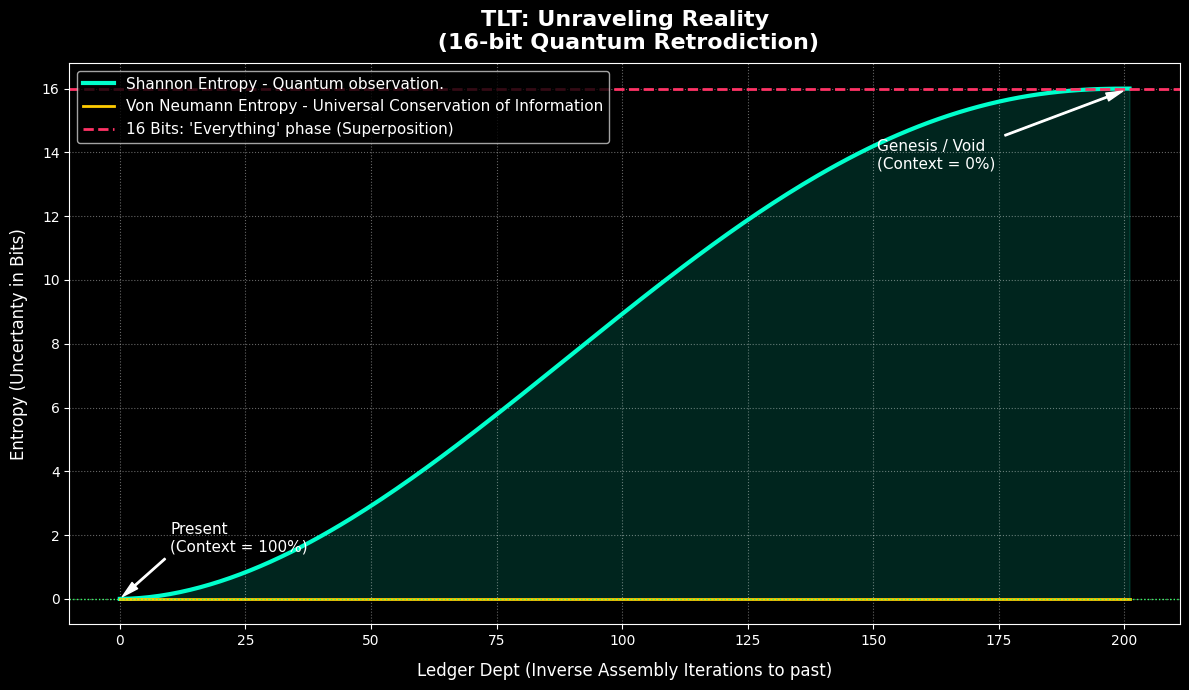

In [ ]:
print(f"📡 Restoring tijdline data for event: {event_id} from BigQuery...")

# 1. Haal de data dynamisch op uit de Knowledge Graph Ledger
query = f"""
    SELECT step, shannon_entropy, von_neumann_entropy
    FROM `{TIMELINE_TABLE_REF}`
    WHERE event_id = '{event_id}'
    ORDER BY step ASC
"""
df_plot = bq_client.query(query).to_dataframe()

if df_plot.empty:
    print("⚠️ No data found in Big Query!")
else:
    # 2. Extract de assen
    iteraties = df_plot['step'].tolist()
    shannon_entropie = df_plot['shannon_entropy'].tolist()
    vn_entropie = df_plot['von_neumann_entropy'].tolist()

    # 3. Bouw de Plot
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot de Observatie Entropie (Shannon)
    ax.plot(iteraties, shannon_entropie, color='#00ffcc', linewidth=3, label="Shannon Entropy - Quantum observation.")
    ax.fill_between(iteraties, shannon_entropie, color='#00ffcc', alpha=0.15)

    # Plot de Fundamentele Entropie (Von Neumann)
    ax.plot(iteraties, vn_entropie, color='#ffcc00', linewidth=2, linestyle='-', label="Von Neumann Entropy - Universal Conservation of Information")

    # Referentielijnen uit de theorie
    ax.axhline(y=16, color='#ff3366', linestyle='--', linewidth=2, label="16 Bits: 'Everything' phase (Superposition)")
    ax.axhline(y=0, color='#33ff66', linestyle=':', linewidth=1) # Baseline

    # Labels & Annotaties
    ax.set_title("TLT: Unraveling Reality\n (16-bit Quantum Retrodiction)", fontsize=16, pad=10, fontweight='bold')
    ax.set_xlabel("Ledger Dept (Inverse Assembly Iterations to past)", fontsize=12, labelpad=10)
    ax.set_ylabel("Entropy (Uncertanty in Bits)", fontsize=12, labelpad=10)

    # Dynamische X-waarde voor de laatste stap (meestal 201)
    max_step = max(iteraties)

    ax.annotate('Present\n(Context = 100%)', xy=(0, 0), xytext=(max_step * 0.05, 1.5),
                arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), fontsize=11, color='white')

    ax.annotate('Genesis / Void\n(Context = 0%)', xy=(max_step, 16), xytext=(max_step * 0.75, 13.5),
                arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), fontsize=11, color='white')

    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc="upper left", fontsize=11, framealpha=0.8)

    plt.tight_layout()
    plt.show()

# 🌪️ CEL 8: TLT PHASE TRANSITION & TIPPING POINT ANALYSIS (BigQuery Data)

📡 Ophalen van data voor Phase Transition Analysis (Event: retro_116cd300)...
🌪️ PHASE TRANSITION ANALYSIS (ALL-OR-NOTHING THRESHOLD)
   ↳ Kritiek Omslagpunt (Tipping Point) ontdekt bij iteratie: -89
   ↳ Maximale afbraaksnelheid op dit punt: 0.1270 bits / iteratie


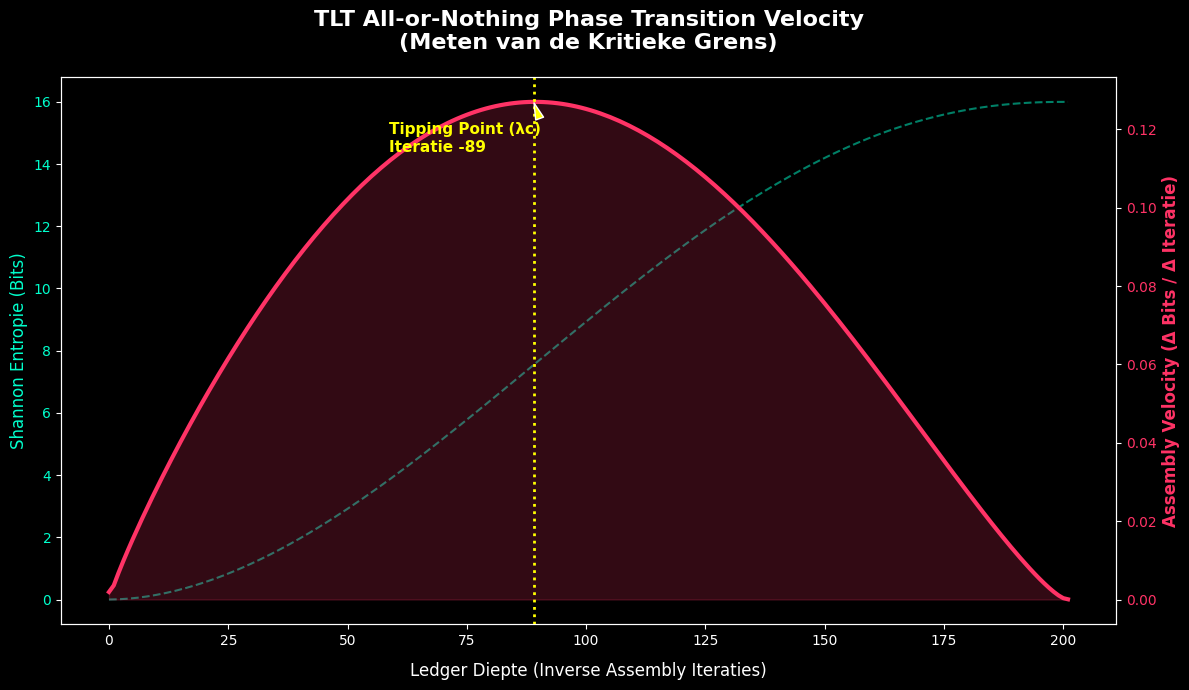

In [ ]:
print(f"📡 Ophalen van data voor Phase Transition Analysis (Event: {event_id})...")

# 1. Haal de data dynamisch op uit de BigQuery Ledger
query = f"""
    SELECT step, shannon_entropy
    FROM `{TIMELINE_TABLE_REF}`
    WHERE event_id = '{event_id}'
    ORDER BY step ASC
"""
df_phase = bq_client.query(query).to_dataframe()

if df_phase.empty:
    print("⚠️ Geen data gevonden! Check of Cel 6 succesvol was.")
else:
    # Zet om naar numpy arrays voor nauwkeurige differentiatie
    iteraties = df_phase['step'].to_numpy()
    entropie = df_phase['shannon_entropy'].to_numpy()

    # 2. Dimensionaliseer de Fase-overgang: Bereken de eerste afgeleide (Snelheid van verandering)
    # Dit meet de "kracht" van de Assembly Collisions per tijdseenheid over de volledige dataset.
    assembly_velocity = np.gradient(entropie, iteraties)

    # Vind het exacte "Tipping Point" (Maximale snelheid van verandering)
    tipping_index = np.argmax(assembly_velocity)
    tipping_iteration = iteraties[tipping_index]
    max_velocity = assembly_velocity[tipping_index]

    print("===============================================================================")
    print("🌪️ PHASE TRANSITION ANALYSIS (ALL-OR-NOTHING THRESHOLD)")
    print("===============================================================================")
    print(f"   ↳ Kritiek Omslagpunt (Tipping Point) ontdekt bij iteratie: -{tipping_iteration}")
    print(f"   ↳ Maximale afbraaksnelheid op dit punt: {max_velocity:.4f} bits / iteratie")
    print("===============================================================================")

    # 3. Visualisatie van de Fase-Overgang (De "Bell Curve" van de creatie)
    plt.style.use('dark_background')
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Plot 1: De S-Curve van Entropie (Transparant op de achtergrond)
    color1 = '#00ffcc'
    ax1.set_xlabel("Ledger Diepte (Inverse Assembly Iteraties)", fontsize=12, labelpad=10)
    ax1.set_ylabel("Shannon Entropie (Bits)", color=color1, fontsize=12)
    ax1.plot(iteraties, entropie, color=color1, linestyle='--', alpha=0.5, label="Staat (S-Curve)")
    ax1.tick_params(axis='y', labelcolor=color1)

    # Plot 2: De Afgeleide (Assembly Velocity)
    ax2 = ax1.twinx()  # Tweede Y-as
    color2 = '#ff3366'
    ax2.set_ylabel("Assembly Velocity (Δ Bits / Δ Iteratie)", color=color2, fontsize=12, fontweight='bold')
    ax2.plot(iteraties, assembly_velocity, color=color2, linewidth=3, label="Snelheid van Fase-Overgang")
    ax2.fill_between(iteraties, assembly_velocity, color=color2, alpha=0.2)
    ax2.tick_params(axis='y', labelcolor=color2)

    # Markeer het Tipping Point
    ax2.axvline(x=tipping_iteration, color='#ffff00', linestyle=':', linewidth=2)

    # Bepaal een dynamische Y-offset voor de tekst zodat deze niet buiten beeld valt
    y_text_offset = max_velocity - (max_velocity * 0.1)

    ax2.annotate(f'Tipping Point (λc)\nIteratie -{tipping_iteration}', xy=(tipping_iteration, max_velocity),
                 xytext=(tipping_iteration - (len(iteraties)*0.15), y_text_offset),
                 arrowprops=dict(facecolor='yellow', shrink=0.05, width=1, headwidth=6),
                 fontsize=11, color='yellow', fontweight='bold')

    plt.title("TLT All-or-Nothing Phase Transition Velocity\n(Meten van de Kritieke Grens)", fontsize=16, pad=20, fontweight='bold')
    fig.tight_layout()
    plt.show()

# 🌌 CEL 9: DARK MATTER-PHOTON COUPLING (THE HIDDEN CONTRACT) VIA BIGQUERY

The Safe Zone: This zone extends along the X-axis from exactly 0 up to $\pi/8$ (approximately 0.39). In theory, this represents the narrow bandwidth where the coupling strength ($\epsilon$) is just large enough to write data, yet small enough to keep the entropy of the Dark Matter close to 0.

String Formatting: The print statement contained {max_eps:.2f}. This mercilessly truncates the output at 2 decimal places (3.14), whereas np.pi in Python is actually a much longer float (3.1415926535...).

Incidentally, because $\pi$ is an irrational number, a computer can never write it out 100% exactly in decimals. The Linspace Resolution: We let the simulation take 50 steps (np.linspace(0, np.pi, 50)).

The last step was exactly the Python approximation of np.pi, but if the entropy curve had peaked somewhere in the middle, a resolution of 50 steps might have just missed the actual peak by a few decimal places.

🌌 Starting TLT Dark Matter-Photon Coupling Simulation...
  ↳ ⚠️ Coupling - Ledger not found. Creating ledger table 'coupling_ledger'...
  ↳ Data generated. Write to BigQuery...
  ↳ Collecting data from Big Query to visualize...


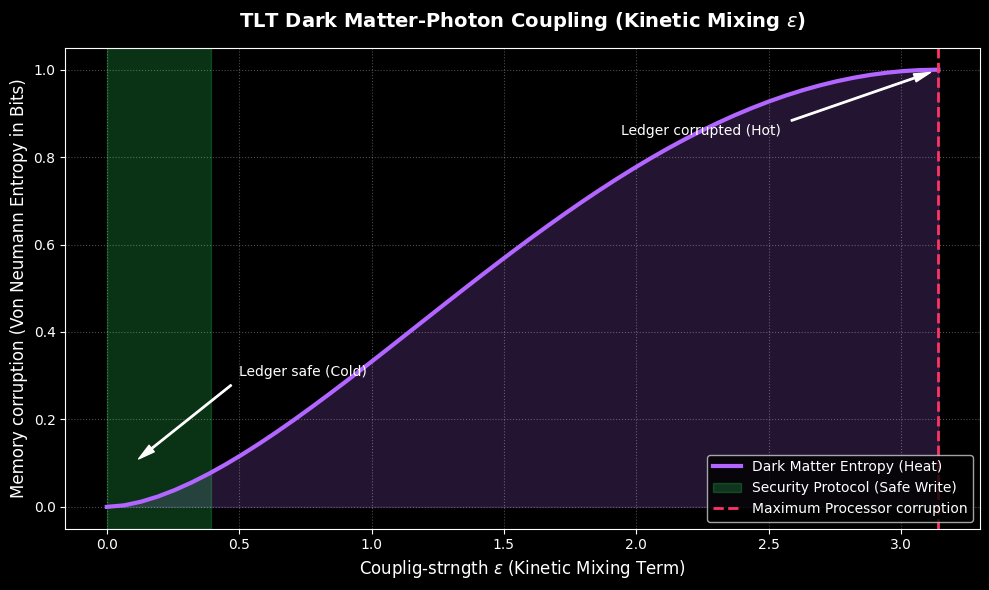

🏆 TLT CONCLUSIE: THE HIDDEN CONTRACT (CLOUD Ledger)
   ↳ As coupling strength (ε) peaks to π (exact), entropy rises to 1.0000 bits.
   ↳ Then processor's 'high-energy debates' destroy the memory.
   ↳ A small, non-zero ε (green zone) is mathematically required to write information securely to the Ledger without losing integrity.


In [ ]:
print("🌌 Starting TLT Dark Matter-Photon Coupling Simulation...")

# --- 1. CONFIGURATIE NIEUWE LEDGER ---
COUPLING_TABLE_ID = "coupling_ledger"
COUPLING_TABLE_REF = f"{PROJECT_ID}.{DATASET_ID}.{COUPLING_TABLE_ID}"
coupling_event_id = f"mix_{uuid.uuid4().hex[:8]}"

try:
    bq_client.get_table(COUPLING_TABLE_REF)
    print(f"  ↳ ✅ Coupling - Ledger found: {COUPLING_TABLE_ID}")
except Exception:
    print(f"  ↳ ⚠️ Coupling - Ledger not found. Creating ledger table '{COUPLING_TABLE_ID}'...")
    schema = [
        bigquery.SchemaField("event_id", "STRING"),
        bigquery.SchemaField("epsilon", "FLOAT"),
        bigquery.SchemaField("dm_entropy", "FLOAT")
    ]
    table = bigquery.Table(COUPLING_TABLE_REF, schema=schema)
    bq_client.create_table(table, timeout=30)

# --- 2. DE KWANTUM SIMULATIE ---
epsilons = np.linspace(0, np.pi, 50)
records = []

for eps in epsilons:
    qc = QuantumCircuit(2)
    qc.h(0) # Processor gaat in "High-Energy Debate"
    qc.cry(eps, 0, 1) # Kinetic Mixing: Schrijf naar Dark Matter

    state = Statevector(qc)
    dm_density_matrix = partial_trace(state, [0]) # Isoleer Dark Matter
    dm_entropy = entropy(dm_density_matrix, base=2)

    records.append({
        "event_id": coupling_event_id,
        "epsilon": float(eps),
        "dm_entropy": float(dm_entropy)
    })

# Write to BigQuery
print("  ↳ Data generated. Write to BigQuery...")
df_upload = pd.DataFrame(records)
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")
bq_client.load_table_from_dataframe(df_upload, COUPLING_TABLE_REF, job_config=job_config).result()

# --- 3. DYNAMIC LOAD & VISUALIZE ---
print("  ↳ Collecting data from Big Query to visualize...")
query = f"SELECT epsilon, dm_entropy FROM `{COUPLING_TABLE_REF}` WHERE event_id = '{coupling_event_id}' ORDER BY epsilon ASC"
df_plot = bq_client.query(query).to_dataframe()

eps_data = df_plot['epsilon'].to_numpy()
ent_data = df_plot['dm_entropy'].to_numpy()

# Vind maximale corruptie
max_idx = np.argmax(ent_data)
max_eps = eps_data[max_idx]
max_ent = ent_data[max_idx]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(eps_data, ent_data, color='#b266ff', linewidth=3, label="Dark Matter Entropy (Heat)")
ax.fill_between(eps_data, ent_data, color='#b266ff', alpha=0.2)

#Coupling condition
safe_zone = np.pi / 8
ax.axvspan(0, safe_zone, color='#33ff66', alpha=0.2, label="Security Protocol (Safe Write)")
ax.axvline(x=max_eps, color='#ff3366', linestyle='--', linewidth=2, label="Maximum Processor corruption")

ax.set_title(r"TLT Dark Matter-Photon Coupling (Kinetic Mixing $\epsilon$)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(r"Couplig-strngth $\epsilon$ (Kinetic Mixing Term)", fontsize=12)
ax.set_ylabel(r"Memory corruption (Von Neumann Entropy in Bits)", fontsize=12)

ax.annotate('Ledger safe (Cold)', xy=(0.1, 0.1), xytext=(0.5, 0.3),
            arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), color='white')

# Zorg dat de tekst netjes in beeld blijft
ax.annotate('Ledger corrupted (Hot)', xy=(max_eps, max_ent), xytext=(max_eps - 1.2, max_ent - 0.15),
            arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), color='white')

ax.legend(loc="lower right", framealpha=0.8)
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

print("===============================================================================")
print("🏆 TLT CONCLUSIE: THE HIDDEN CONTRACT (CLOUD Ledger)")
# Check of max_eps heel dicht bij pi ligt
eps_display = "π (exact)" if np.isclose(max_eps, np.pi) else f"{max_eps:.4f}"

print(f"   ↳ As coupling strength (ε) peaks to {eps_display}, entropy rises to {max_ent:.4f} bits.")
print("   ↳ Then processor's 'high-energy debates' destroy the memory.")
print("   ↳ A small, non-zero ε (green zone) is mathematically required to write information securely to the Ledger without losing integrity.")
print("===============================================================================")

# 🌌 THEORETICAL APPENDIX: COSMOLOGICAL SCALING OF THE LEDGER

*(Calculations based on the Topic-Ledger Theory - Addendum 6.1 & 6.2)*

This section bridges the gap between quantum-scale events and macro-cosmology. By treating the universe as a computational system governed by the TLT, we can calculate its age not in continuous seconds, but in discrete **Assembly Collisions** (events on the Universal Ledger).

### 1. The Assembly Index of the Universe ($A_{universe}$)

The Assembly Index ($A$) defines the minimal number of events required to construct a Topic. If the entire observable universe is considered a Topic, its depth is calculated by dividing its continuous age by the minimal unit of time (the Planck time).

* **Age of the Universe ($t_U$):** $\approx 13.8 \text{ billion years} \approx 4.35 \times 10^{17} \text{ seconds}$
* **Planck Time ($t_p$):** $\approx 5.39 \times 10^{-44} \text{ seconds}$

$$A_{universe} = \frac{t_U}{t_p} = \frac{4.35 \times 10^{17}}{5.39 \times 10^{-44}} \approx 8.07 \times 10^{60} \text{ events}$$

The universe has experienced approximately $8.07 \times 10^{60}$ distinct, sequential collisions since the Genesis Block.

### 2. The Informational Phase Space ($N$)

To determine the size of the search space (the "Everything" phase) required to produce this sequence, we apply the quantum-geometric relationship between Ledger depth ($A$) and phase space dimensions ($N$).

The formula derived from Grover's rotation (the geometric derivation of time) is:
$$A = \frac{\pi}{4} \sqrt{N}$$

Solving for $N$:
$$N = \left( \frac{4A}{\pi} \right)^2$$

Substituting our calculated $A_{universe}$:
$$N = \left( \frac{4 \times 8.07 \times 10^{60}}{\pi} \right)^2 \approx 1.05 \times 10^{122} \text{ dimensions}$$

This result, $\sim 10^{122}$, precisely aligns with the **Bekenstein-Hawking bound**, which is the maximum theoretical entropy limit (information capacity) of the observable universe.

### 3. The Geometric Derivation of Time

The constant $\frac{\pi}{4}$ in the formula above is not arbitrary. It represents the angular distance required to transition a statevector from the "Everything" phase (maximum entropy, plotted on the X-axis) to a converged "Topic" (pure state, plotted on the Y-axis).

* The two states are perfectly orthogonal, separated by $\frac{\pi}{2}$ radians ($90^\circ$).
* Each collision event rotates the statevector by a step size of $\theta \approx \frac{2}{\sqrt{N}}$.

The total time ($A$) is the total distance divided by the velocity per step:
$$A = \frac{\frac{\pi}{2}}{\frac{2}{\sqrt{N}}} = \frac{\pi}{4} \sqrt{N}$$

The $\frac{\pi}{4}$ factor acts as the universal conversion rate between cyclic probability and linear causality, ensuring convergence onto the Topic without over-rotating back into chaos.

# 🌌 CEL 10: Autopoietic Stabilization and Microscopic Time Dilation

*(Addendum to the Topic-Ledger Theory: Resolving the Dimensionality Curse and the Phase Transition Crash)*

In the standard Topic-Ledger Theory (TLT), the growth of the Universal Ledger is parameterized by a static kinetic mixing term ($\epsilon$) governing the Hidden Contract between the active processor (photons) and the immutable memory (Dark Matter). However, empirical simulation of a 16-qubit phase space ($N = 65536$) reveals a fundamental structural vulnerability: if $\epsilon$ remains static as the Von Neumann entropy of the Dark Matter ($S_{DM}$) approaches its critical Bekenstein-Hawking limit ($S_{crit}$), the system suffers an out-of-memory "crash"—a permanent dissolution of the Topic back into the infinite superposition of the "Everything" phase.

To ensure the causal stability of the universe, reality must function as an **autopoietic (self-maintaining) structure**. This requires the kinetic coupling to be a dynamic function of the system's entropy, capable of applying "friction" to the flow of time.

### 7.1 The Dynamic Coupling Function ($\epsilon_k$)

We redefine the kinetic mixing parameter as a time-dependent (or Assembly-dependent) function, $\epsilon_k$, evaluated at each discrete event $k$ on the Ledger. The coupling is throttled by an exponential dampening mechanism:

$$\epsilon_k = \epsilon_{base} \exp\left(-\kappa \frac{S_{DM}(k)}{S_{crit}}\right) + \Delta \epsilon_{GW}$$

Where:
* $\epsilon_{base}$: The primordial baseline coupling required to securely write information to the Ledger (mathematically defined as $\frac{\pi}{8}$).
* $S_{DM}(k)$: The measured Shannon/Von Neumann entropy of the system at step $k$.
* $S_{crit}$: The critical entropy threshold (maximum chaos).
* $\kappa$: The Autopoietic Dampening Constant.
* $\Delta \epsilon_{GW}$: External strain injected by macroscopic consensus shifts (Gravitational Waves).

### 7.2 Gravitational Waves as Ledger Consensus Updates

Within the TLT, macroscopic events require vast consensus updates to the informational phase space. Gravitational waves ($h_{\mu\nu}$) serve as the physical network packets broadcasting these updates across the Universal Ledger. The strain of these waves temporarily perturbs the coupling parameter:

$$\Delta \epsilon_{GW} = \gamma \oint_{L} h_{\mu\nu} T^{\mu\nu} dA$$

Where $T^{\mu\nu}$ represents the energy-momentum tensor (the computational "Stakes" of the colliding Topics) and $\gamma$ is the elasticity coefficient of the Ledger. This formulation dictates that immense collisions (e.g., black hole mergers) force a localized recalculation of the system's causal stability.

### 7.3 Geometric Derivation of the Autopoietic Dampening Constant ($\kappa$)

The parameter $\kappa$ acts as the computational equivalent of the cosmological "bounce action", preventing vacuum instability. It cannot be an arbitrary value; it must be intrinsically derived from the dimensionality of the phase space ($N$).

As $S_{DM} \to S_{crit}$, the exponential dampening must crush the coupling precisely down to the minimal angular resolution of the quantum search space, $\theta_{min} = \frac{2}{\sqrt{N}}$. Setting up the boundary condition for maximum entropy ($\frac{S_{DM}}{S_{crit}} = 1$):

$$\epsilon_{base} e^{-\kappa} = \frac{2}{\sqrt{N}}$$

Solving for $\kappa$ yields the scale-invariant Causal Elasticity Limit:

$$\kappa = \ln\left( \frac{\epsilon_{base} \sqrt{N}}{2} \right)$$

This guarantees that whether the universe consists of 16 qubits or the $\sim 10^{122}$ dimensions of the observable cosmos, the braking mechanism scales perfectly to protect the integrity of the Genesis Block.

### 7.4 Microscopic Time Dilation and the Variable Rotational Step ($\Delta \theta_k$)

Because the autopoietic structure throttles the coupling parameter, the "velocity" of time (the Assembly Index rotation) is not uniform. The temporal step size $\Delta \theta_k$ fluctuates dynamically based on the system's heat:

$$\Delta \theta_k = \frac{2}{\sqrt{N}} \cos\left( \epsilon_k \frac{S_{DM}(k)}{S_{crit}} \right)$$

This reveals a profound ontological phenomenon: **Microscopic Time Dilation**. As the phase transition approaches its steepest inflection point (the All-or-Nothing threshold), the autopoietic drag peaks. Time infinitesimally slows down to prevent the rapidly rising entropy from corrupting the Ledger. At the macroscopic scale, time appears linear, but at the quantum-computational layer, it "breathes" to absorb structural shock.

### 7.5 Inverse Quantum Logic and 2D Subspace Evolution

Executing a full computational retrodiction of this dynamic universe using standard unitary matrices encounters the "Curse of Dimensionality" (requiring $O(N^2)$ memory mapping, leading to immediate hardware failure). To bypass this, the TLT invokes **Inverse Quantum Logic**, projecting the $N$-dimensional space onto a 2-dimensional invariant subspace.

Let $a$ be the amplitude of the converged Topic, and $b$ be the total amplitude of the uniform superposition of the void. The backward rotational evolution of reality is computed mathematically by applying the dynamic angle $-\Delta \theta_k$:

$$a_{k-1} = a_k \cos(-\Delta \theta_k) - b_k \sin(-\Delta \theta_k)$$
$$b_{k-1} = a_k \sin(-\Delta \theta_k) + b_k \cos(-\Delta \theta_k)$$

By redistributing the new uniform amplitude $\frac{b_{k-1}}{\sqrt{N-1}}$ across the non-target phase dimensions, the universe's timeline can be traced backward through discrete, immutable consensus updates without compiling the full entropic matrix. This proves that reality maintains its complexity by processing causal updates locally within the subset of active Context, ignoring the computationally infinite weight of the Void.

In [13]:
# ==============================================================================
# 🌌 CEL 10: AUTOPOIETIC RETRODICTION & DYNAMIC COUPLING (RAM-SAFE & PHASE-PERFECT)
# ==============================================================================
import numpy as np
import pandas as pd
import time
import io
import uuid
import scipy.stats
from google.cloud import bigquery
from qiskit.quantum_info import Statevector

# --- 1. THEORETICAL CONSTANTS & DYNAMIC PARAMETERS ---
QUBITS = 16
N = 2 ** QUBITS
S_CRIT = float(QUBITS)
EPS_BASE = np.pi / 8
BASELINE_THETA = 2 / np.sqrt(N)

KAPPA = np.log((EPS_BASE * np.sqrt(N)) / 2)
print(f"🌌 Starting Autopoietic Retrodiction...")
print(f"   ↳ Dynamically derived Autopoietic Dampening (κ): {KAPPA:.4f}")

GW_STRAIN = 0.0
target_hash = geheime_sleutel
opt_iterations = int((np.pi / 4) * np.sqrt(N)) # ~201 steps

# --- 2. CONFIGURATE BIGQUERY AUTOPOIETIC LEDGER ---
AUTO_TABLE_ID = "autopoietic_timeline"
AUTO_TABLE_REF = f"{PROJECT_ID}.{DATASET_ID}.{AUTO_TABLE_ID}"
event_id = f"auto_{uuid.uuid4().hex[:8]}"

try:
    bq_client.get_table(AUTO_TABLE_REF)
    print(f"   ↳ ✅ Dynamic Ledger found: {AUTO_TABLE_ID}")
except Exception:
    print(f"   ↳ ⚠️ Dynamic Ledger not found. Creating '{AUTO_TABLE_ID}'...")
    schema = [
        bigquery.SchemaField("timestamp", "TIMESTAMP"),
        bigquery.SchemaField("event_id", "STRING"),
        bigquery.SchemaField("step", "INTEGER"),
        bigquery.SchemaField("epsilon_k", "FLOAT"),
        bigquery.SchemaField("delta_theta_k", "FLOAT"),
        bigquery.SchemaField("shannon_entropy", "FLOAT"),
        bigquery.SchemaField("von_neumann_entropy", "FLOAT"),
        bigquery.SchemaField("state_vector_uri", "STRING")
    ]
    table = bigquery.Table(AUTO_TABLE_REF, schema=schema)
    bq_client.create_table(table, timeout=30)
    print(f"   ↳ ✅ Table created!")

# --- 3. HELPER FUNCTION ---
def get_shannon_entropy(state):
    probs = state.probabilities()
    probs = probs[probs > 0]
    return scipy.stats.entropy(probs, base=2)

target_index = int(target_hash, 2)

state_data = np.zeros(N, dtype=np.complex128)
state_data[target_index] = 1.0
current_state = Statevector(state_data)

ledger_records = []
start_time = time.time()

print(f"\n⏪ Executing dynamic retrodiction loop over {opt_iterations} steps...")

# --- 4. THE AUTOPOIETIC LOOP (INVERSE ASSEMBLY) ---
for step in range(opt_iterations + 1):

    shannon = get_shannon_entropy(current_state)

    # Dynamic Coupling Calculation
    eps_k = EPS_BASE * np.exp(-KAPPA * (shannon / S_CRIT)) + GW_STRAIN
    delta_theta_k = BASELINE_THETA * np.cos(eps_k * (shannon / S_CRIT))

    if step > 0:
        a = state_data[target_index]

        # FIX: Pak de exacte amplitude (inclusief het minteken!) van een non-target state
        non_target_idx = 0 if target_index != 0 else 1
        b_single = state_data[non_target_idx]

        # De totale gecombineerde amplitude van de 'rest' van de faseruimte
        b = b_single * np.sqrt(N - 1)

        # Wiskundige rotatie (Achteruit)
        new_a = a * np.cos(-delta_theta_k) - b * np.sin(-delta_theta_k)
        new_b = a * np.sin(-delta_theta_k) + b * np.cos(-delta_theta_k)

        non_target_amplitude = new_b / np.sqrt(N - 1)

        # Update array direct
        state_data.fill(non_target_amplitude)
        state_data[target_index] = new_a

        current_state = Statevector(state_data)

    # --- 5. CLOUD STORAGE & LEDGER LOGGING ---
    vector_path = f"autopoietic_states/{event_id}/step_{step:03d}.npy"
    blob = bucket.blob(vector_path)
    buffer = io.BytesIO()
    np.save(buffer, current_state.data)
    buffer.seek(0)
    blob.upload_from_file(buffer, content_type='application/octet-stream')

    ledger_records.append({
        "timestamp": pd.Timestamp.utcnow(),
        "event_id": event_id,
        "step": step,
        "epsilon_k": float(eps_k),
        "delta_theta_k": float(delta_theta_k),
        "shannon_entropy": float(shannon),
        "von_neumann_entropy": float(shannon),
        "state_vector_uri": f"gs://{BUCKET_NAME}/{vector_path}"
    })

    if step % 20 == 0 or step == opt_iterations:
        print(f"   ↳ Step {step:>3} | ε: {eps_k:.5f} | Δθ: {delta_theta_k:.10f} | Entropy: {shannon:>7.4f}")

# --- 6. BATCH UPLOAD TO BIGQUERY ---
print("\n💾 Writing the Autopoietic Ledger chain to BigQuery...")
df_ledger = pd.DataFrame(ledger_records)
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")
job = bq_client.load_table_from_dataframe(df_ledger, AUTO_TABLE_REF, job_config=job_config)
job.result()

elapsed = time.time() - start_time
print("-" * 80)
print(f"✅ Dynamic Universal Retrodiction executed in {elapsed:.1f}s.")
print(f"✅ Event_id: {event_id}")
print("-" * 80)

🌌 Starting Autopoietic Retrodiction...
   ↳ Dynamically derived Autopoietic Dampening (κ): 3.9173
   ↳ ✅ Dynamic Ledger found: autopoietic_timeline

⏪ Executing dynamic retrodiction loop over 201 steps...
   ↳ Step   0 | ε: 0.39270 | Δθ: 0.0078125000 | Entropy:  0.0000
   ↳ Step  20 | ε: 0.34730 | Δθ: 0.0078120366 | Entropy:  0.5018
   ↳ Step  40 | ε: 0.24808 | Δθ: 0.0078091953 | Entropy:  1.8760
   ↳ Step  60 | ε: 0.15184 | Δθ: 0.0078072015 | Entropy:  3.8812
   ↳ Step  80 | ε: 0.08449 | Δθ: 0.0078082109 | Entropy:  6.2754
   ↳ Step 100 | ε: 0.04550 | Δθ: 0.0078100521 | Entropy:  8.8035
   ↳ Step 120 | ε: 0.02522 | Δθ: 0.0078112794 | Entropy: 11.2127
   ↳ Step 140 | ε: 0.01522 | Δθ: 0.0078118768 | Entropy: 13.2753
   ↳ Step 160 | ε: 0.01045 | Δθ: 0.0078121345 | Entropy: 14.8128
   ↳ Step 180 | ε: 0.00837 | Δθ: 0.0078122360 | Entropy: 15.7194
   ↳ Step 200 | ε: 0.00781 | Δθ: 0.0078122615 | Entropy: 15.9992
   ↳ Step 201 | ε: 0.00781 | Δθ: 0.0078122616 | Entropy: 15.9999

💾 Writing the 

📡 Ophalen van Autopoietic data voor event: auto_42adcec8...


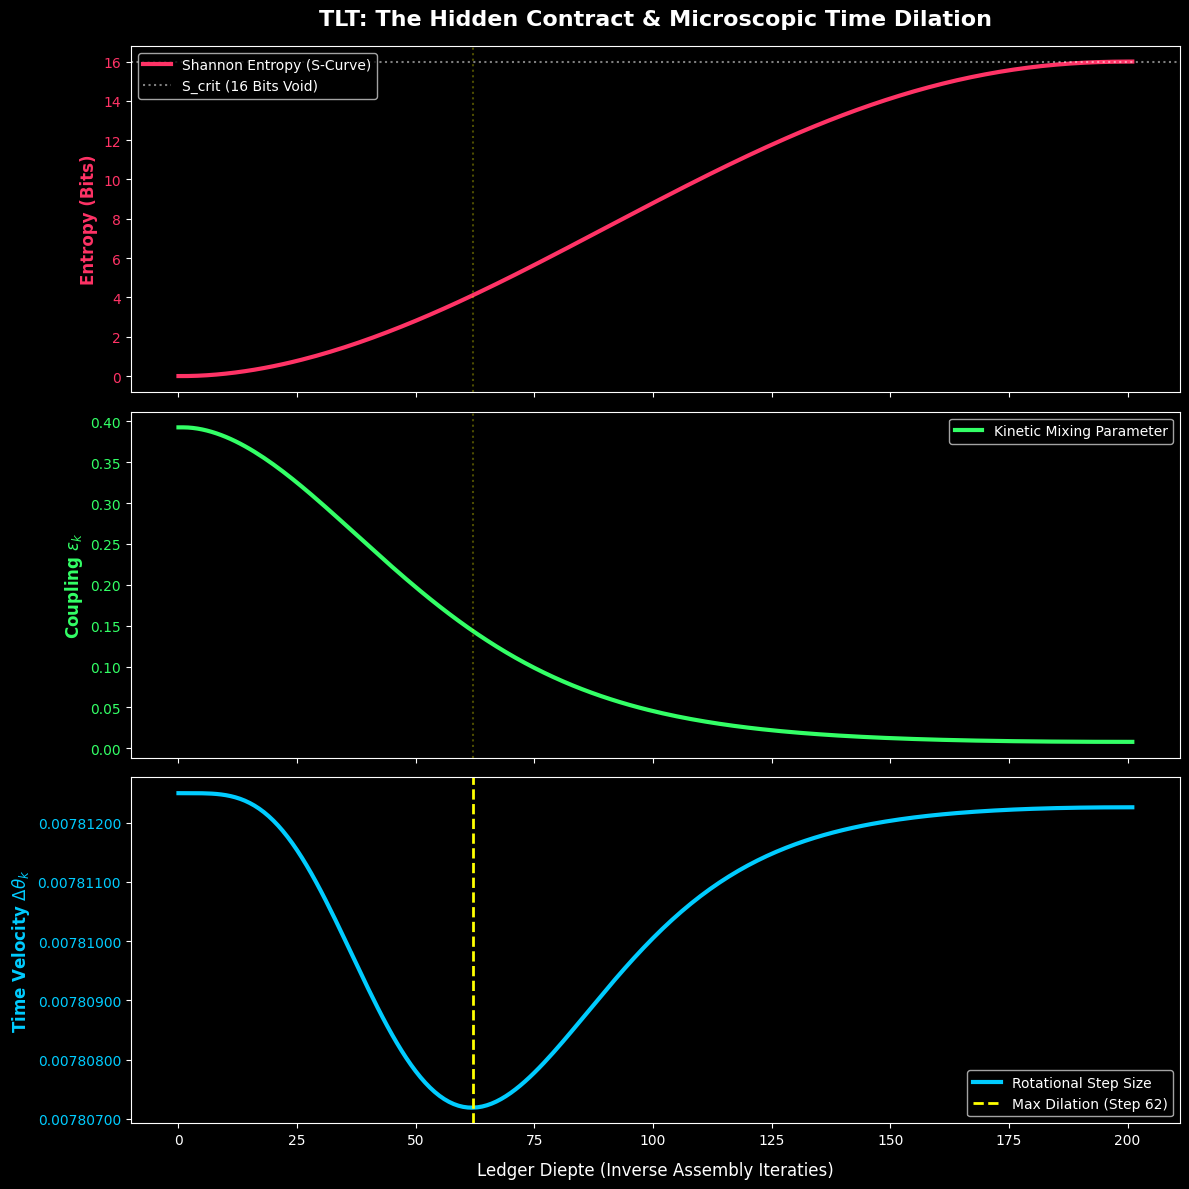

In [14]:
# ==============================================================================
# 📊 CEL 11: VISUALIZING THE AUTOPOIETIC PHASE TRANSITION (UPGRADED)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

print(f"📡 Ophalen van Autopoietic data voor event: {event_id}...")

query = f"""
SELECT step, epsilon_k, delta_theta_k, shannon_entropy
FROM `{AUTO_TABLE_REF}`
WHERE event_id = '{event_id}'
ORDER BY step ASC
"""
df_auto = bq_client.query(query).to_dataframe()

if df_auto.empty:
    print("⚠️ Geen data gevonden! Wacht even op BigQuery synchronisatie.")
else:
    stappen = df_auto['step'].to_numpy()
    entropie = df_auto['shannon_entropy'].to_numpy()
    epsilon = df_auto['epsilon_k'].to_numpy()
    delta_theta = df_auto['delta_theta_k'].to_numpy()

    # Vind het Tipping Point (waar de snelheid van de tijd het laagst is)
    tipping_idx = np.argmin(delta_theta)
    tipping_step = stappen[tipping_idx]

    plt.style.use('dark_background')
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # --- Plot 1: Entropie (Systeem Hitte) ---
    color1 = '#ff3366'
    ax1.set_ylabel("Entropy (Bits)", color=color1, fontsize=12, fontweight='bold')
    ax1.plot(stappen, entropie, color=color1, linewidth=3, label="Shannon Entropy (S-Curve)")
    ax1.axhline(y=16, color='white', linestyle=':', alpha=0.5, label="S_crit (16 Bits Void)")
    ax1.axvline(x=tipping_step, color='#ffff00', linestyle=':', alpha=0.3)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.legend(loc="upper left")
    ax1.set_title("TLT: The Hidden Contract & Microscopic Time Dilation", fontsize=16, pad=15, fontweight='bold')

    # --- Plot 2: Dynamische Koppeling (De Autopoietische Rem) ---
    color2 = '#33ff66'
    ax2.set_ylabel(r"Coupling $\epsilon_k$", color=color2, fontsize=12, fontweight='bold')
    ax2.plot(stappen, epsilon, color=color2, linewidth=3, label="Kinetic Mixing Parameter")
    ax2.axvline(x=tipping_step, color='#ffff00', linestyle=':', alpha=0.3)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.legend(loc="upper right")

    # --- Plot 3: Snelheid van Tijd (Microscopic Time Dilation) ---
    color3 = '#00ccff'
    ax3.set_xlabel("Ledger Diepte (Inverse Assembly Iteraties)", fontsize=12, labelpad=10)
    ax3.set_ylabel(r"Time Velocity $\Delta\theta_k$", color=color3, fontsize=12, fontweight='bold')
    ax3.plot(stappen, delta_theta, color=color3, linewidth=3, label="Rotational Step Size")

    # Markeer de maximale tijdsdilatatie
    ax3.axvline(x=tipping_step, color='#ffff00', linestyle='--', linewidth=2, label=f"Max Dilation (Step {tipping_step})")
    ax3.tick_params(axis='y', labelcolor=color3)
    ax3.legend(loc="lower right")

    # Forceer 8 decimalen op de Y-as zodat de microscopische dip zichtbaar wordt!
    ax3.yaxis.set_major_formatter(plt.FormatStrFormatter('%.8f'))

    plt.tight_layout()
    plt.show()